In [ ]:
import pandas as pd
import numpy as np

# visualization

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import matplotlib.dates as mdates

# scaler

from sklearn.preprocessing import RobustScaler

# model

from sklearn.linear_model import LinearRegression

# metrics

from sklearn.metrics import mean_squared_error,root_mean_squared_error, mean_absolute_percentage_error, r2_score

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/processed_data.xlsx')

# Train-Validation-Test Splits

In [ ]:
X_train = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/X_train_cost_prediction.xlsx')
y_train = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/y_train_cost_prediction.xlsx')
X_test = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/X_test_cost_prediction.xlsx')
y_test = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/y_test_cost_prediction.xlsx')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (196, 10)
X_test shape: (49, 10)
y_train shape: (196, 1)
y_test shape: (49, 1)


# Linear Regression Model

In [ ]:
model_lr = LinearRegression(fit_intercept = True)
model_lr.fit(X_train, y_train)

LinearRegression()

# Linear Regression Prediction

In [ ]:
lr_pred = model_lr.predict(X_train)

In [ ]:
def plot_regression_results(y_true, y_pred, title='Regression Predictions'):

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    plt.figure(figsize=(10, 6))

    plt.scatter(y_true, y_pred, alpha=0.6, label='Actual vs. Predicted')

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--',
        label='Ideal Prediction (y=x)'
    )

    plt.title(title)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.4f}')

    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f'MAPE: {mape:.4f}')

    r2 = r2_score(y_true, y_pred)
    print(f'R2: {r2:.4f}')

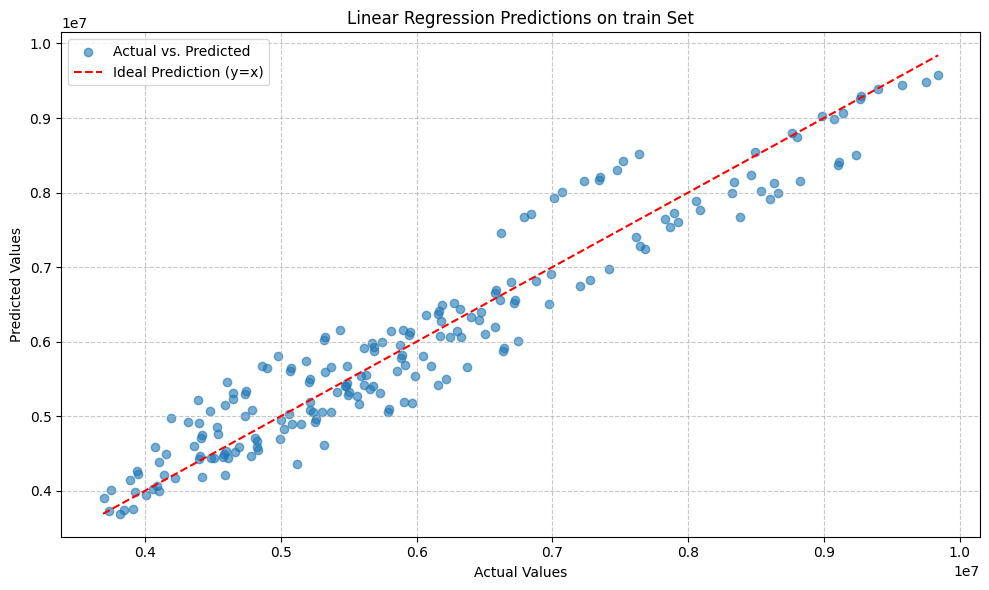

RMSE: 428002.1972
MAPE: 0.0584
R2: 0.9198


In [ ]:
plot_regression_results(y_train, lr_pred, title='Linear Regression Predictions on train Set')

# Residual and R2 Plots

In [ ]:
def residual_plot(y_true, y_pred):

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    residuals = y_true - y_pred

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        alpha=0.6
    )

    plt.axhline(y=0, color='r', linestyle='--')

    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

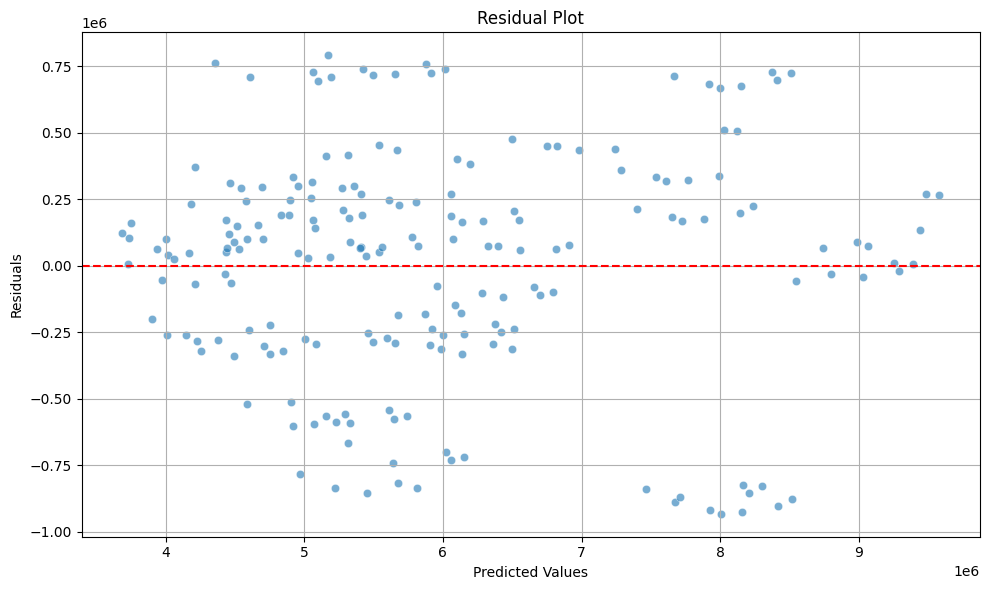

In [ ]:
residual_plot(y_train, lr_pred)

# Feature Importance

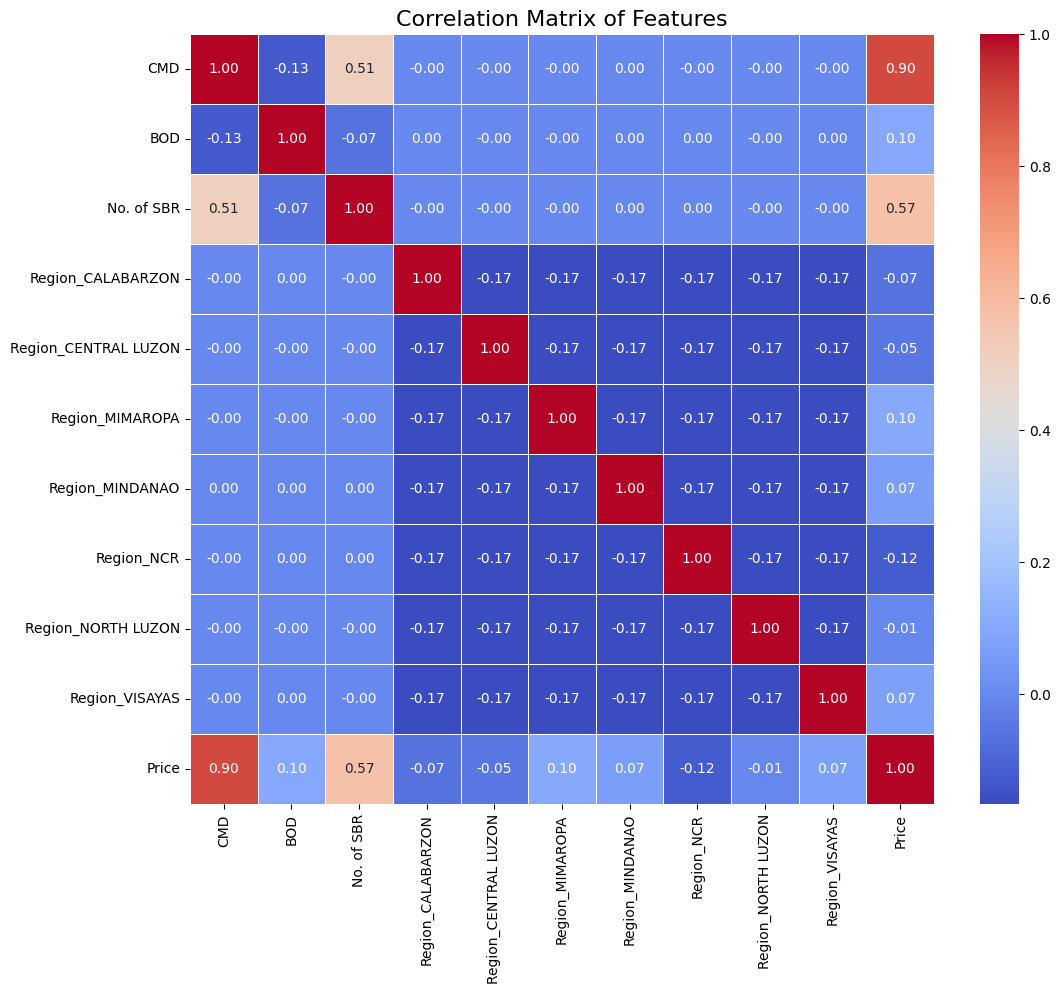

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

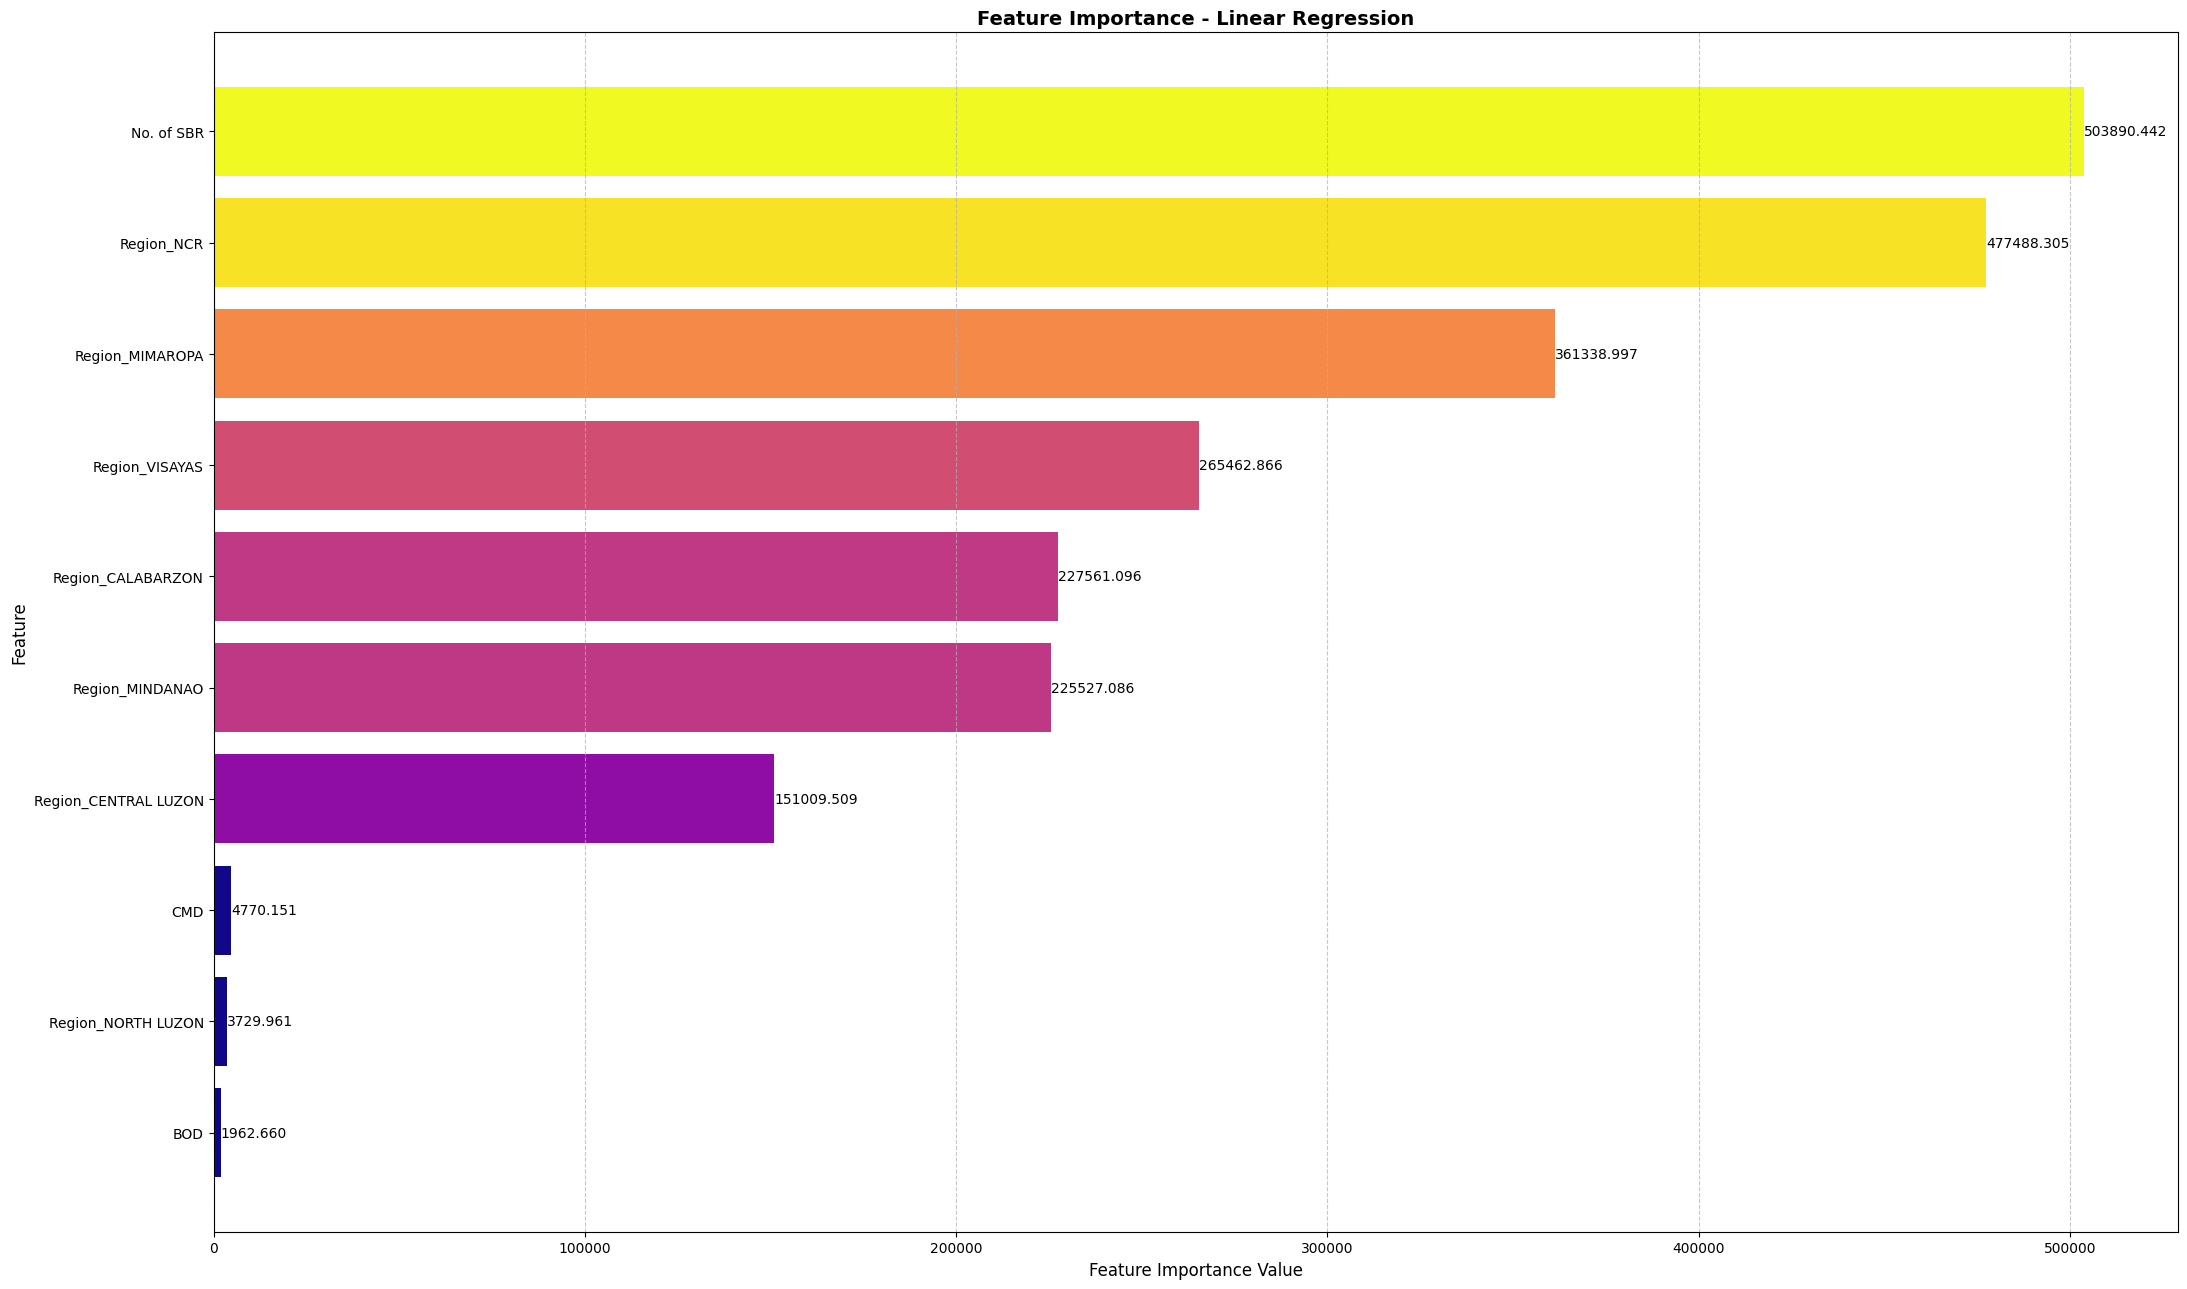

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(model_lr.coef_).flatten()
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(22, 13))

colors = plt.cm.plasma(feature_importance['Importance'] / feature_importance['Importance'].max())

bars = plt.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Importance'][::-1],
    color=colors[::-1]
)

plt.xlabel('Feature Importance Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance - Linear Regression', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.3f}',
             va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()


---
Based on the feature importance and the correlation matrix, both were conflicted because the baseline model was not scaled; but since this is just a baseline model further processing was not performed.

---

